In [1]:
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "apartments_for_rent_classified_100K.csv"

df = pd.read_csv(
    file_path,
    sep=";",
    encoding="cp1252",
    low_memory=False
)

print("Dataset successfully loaded.")

Dataset successfully loaded.


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

display(df.head())

Number of rows: 99492
Number of columns: 22


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,...,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,...,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  object 
 2   title          99492 non-null  object 
 3   body           99492 non-null  object 
 4   amenities      83448 non-null  object 
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  object 
 8   fee            99492 non-null  object 
 9   has_photo      99492 non-null  object 
 10  pets_allowed   39068 non-null  object 
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  object 
 13  price_type     99492 non-null  object 
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   object 
 16  cityname       99190 non-null  object 
 17  state          99190 non-null  object 
 18  latitu

In [5]:
data_type_summary = df.dtypes.value_counts()

print(data_type_summary)

object     14
float64     5
int64       3
Name: count, dtype: int64


In [6]:
unique_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(dropna=False)
})

display(unique_summary)

,Data Type,Unique Values
id,int64,99408
category,object,7
title,object,58503
body,object,94503
amenities,object,9828
bathrooms,float64,17
bedrooms,float64,11
currency,object,1
fee,object,2
has_photo,object,3


In [7]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_summary = (
    missing_summary[missing_summary["Missing Count"] > 0]
    .sort_values("Missing Percentage", ascending=False)
)

display(missing_summary.round(2))

,Missing Count,Missing Percentage
address,91549,92.02
pets_allowed,60424,60.73
amenities,16044,16.13
cityname,302,0.30
state,302,0.30
bedrooms,124,0.12
bathrooms,63,0.06
latitude,25,0.03
longitude,25,0.03
price,1,0.00


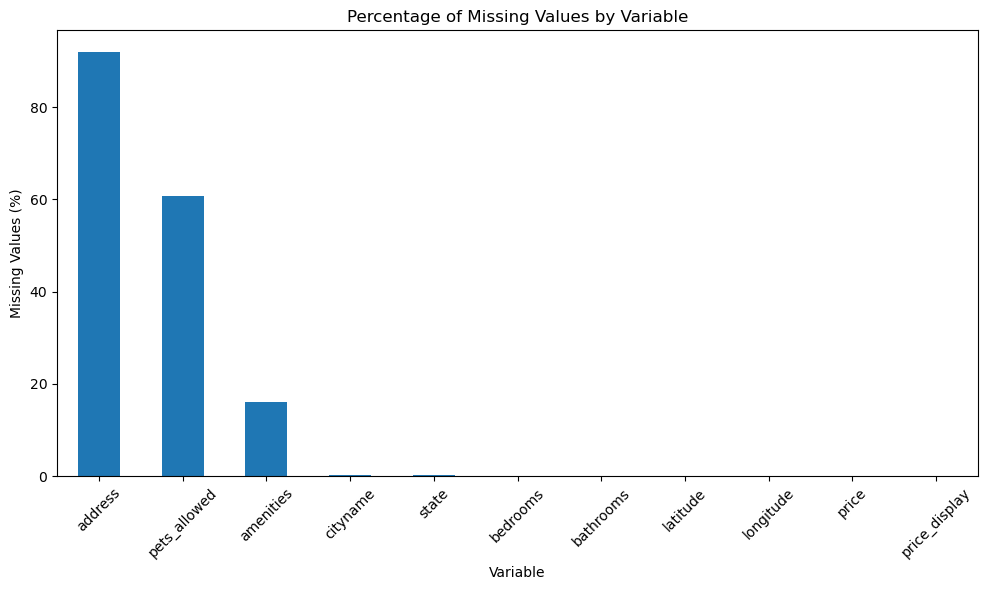

In [8]:
plt.figure(figsize=(10, 6))

missing_summary["Missing Percentage"].plot(kind="bar")

plt.title("Percentage of Missing Values by Variable")
plt.xlabel("Variable")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
exact_duplicates = df.duplicated().sum()

print("Number of exact duplicate rows:", exact_duplicates)

Number of exact duplicate rows: 84


In [10]:
duplicate_ids = df["id"].duplicated().sum()

print("Number of duplicated IDs:", duplicate_ids)

Number of duplicated IDs: 84


In [11]:
duplicate_records = df[df.duplicated(keep=False)]

display(
    duplicate_records
    .sort_values("id")
    .head(10)
)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
79465,5195387513,housing/rent/apartment,Townhome like Duplex,Lemon Grove two Level Upgraded 2 Beds attached...,"Dishwasher,Washer Dryer",1.5,2.0,USD,No,Thumbnail,...,"$2,450",Monthly,820,7241 Balkis,Lemon Grove,CA,32.7331,-117.0332,RentDigs.com,1550653888
83210,5195387513,housing/rent/apartment,Townhome like Duplex,Lemon Grove two Level Upgraded 2 Beds attached...,"Dishwasher,Washer Dryer",1.5,2.0,USD,No,Thumbnail,...,"$2,450",Monthly,820,7241 Balkis,Lemon Grove,CA,32.7331,-117.0332,RentDigs.com,1550653888
79464,5197678700,housing/rent/apartment,This Apartment is a must see!,"Square footage: 983 square ft, unit number: 07...",NaN,1.0,3.0,USD,No,Yes,...,"$1,489",Monthly,983,NaN,Memphis,TN,35.1478,-90.0521,RentDigs.com,1550812916
83209,5197678700,housing/rent/apartment,This Apartment is a must see!,"Square footage: 983 square ft, unit number: 07...",NaN,1.0,3.0,USD,No,Yes,...,"$1,489",Monthly,983,NaN,Memphis,TN,35.1478,-90.0521,RentDigs.com,1550812916
79463,5197682059,housing/rent/apartment,"Spacious One BR, One BA","The of Olathe, a great you canhome where we ta...","Gym,Playground,Pool",1.0,1.0,USD,No,Yes,...,$832,Monthly,660,NaN,Olathe,KS,38.8843,-94.8710,RentDigs.com,1550813171
83208,5197682059,housing/rent/apartment,"Spacious One BR, One BA","The of Olathe, a great you canhome where we ta...","Gym,Playground,Pool",1.0,1.0,USD,No,Yes,...,$832,Monthly,660,NaN,Olathe,KS,38.8843,-94.8710,RentDigs.com,1550813171
83247,5197828778,housing/rent/apartment,"Two BA - $1,862/mo - Apartment - in a great ar...",In the heart of vibrant Tempe near Arizona Sta...,"Gym,Parking,Pool",2.0,3.0,USD,No,Yes,...,"$1,862",Monthly,1261,NaN,Tempe,AZ,33.3924,-111.9265,RentDigs.com,1550823077
79502,5197828778,housing/rent/apartment,"Two BA - $1,862/mo - Apartment - in a great ar...",In the heart of vibrant Tempe near Arizona Sta...,"Gym,Parking,Pool",2.0,3.0,USD,No,Yes,...,"$1,862",Monthly,1261,NaN,Tempe,AZ,33.3924,-111.9265,RentDigs.com,1550823077
83246,5197828852,housing/rent/apartment,The Best of the Best in the City of Tempe! Sav...,In the heart of vibrant Tempe near Arizona Sta...,"Gym,Parking,Pool",2.0,3.0,USD,No,Yes,...,"$1,877",Monthly,1261,NaN,Tempe,AZ,33.3924,-111.9265,RentDigs.com,1550823091
79501,5197828852,housing/rent/apartment,The Best of the Best in the City of Tempe! Sav...,In the heart of vibrant Tempe near Arizona Sta...,"Gym,Parking,Pool",2.0,3.0,USD,No,Yes,...,"$1,877",Monthly,1261,NaN,Tempe,AZ,33.3924,-111.9265,RentDigs.com,1550823091


In [12]:
numerical_variables = [
    "bathrooms",
    "bedrooms",
    "price",
    "square_feet",
    "latitude",
    "longitude"
]

numerical_summary = df[numerical_variables].describe().T

numerical_summary["median"] = df[numerical_variables].median()
numerical_summary["skewness"] = df[numerical_variables].skew()

display(numerical_summary.round(2))

,count,mean,std,min,25%,50%,75%,max,median,skewness
bathrooms,99429.0,1.45,0.55,1.00,1.00,1.00,2.00,9.00,1.00,0.99
bedrooms,99368.0,1.73,0.75,0.00,1.00,2.00,2.00,9.00,2.00,0.88
price,99491.0,1527.06,904.25,100.00,1013.00,1350.00,1795.00,52500.00,1350.00,9.96
square_feet,99492.0,956.43,417.57,101.00,729.00,900.00,1115.00,50000.00,900.00,27.13
latitude,99467.0,36.95,4.60,19.57,33.75,37.23,39.95,64.83,37.23,0.01
longitude,99467.0,-91.57,15.82,-159.37,-104.79,-84.56,-77.61,-68.78,-84.56,-0.63


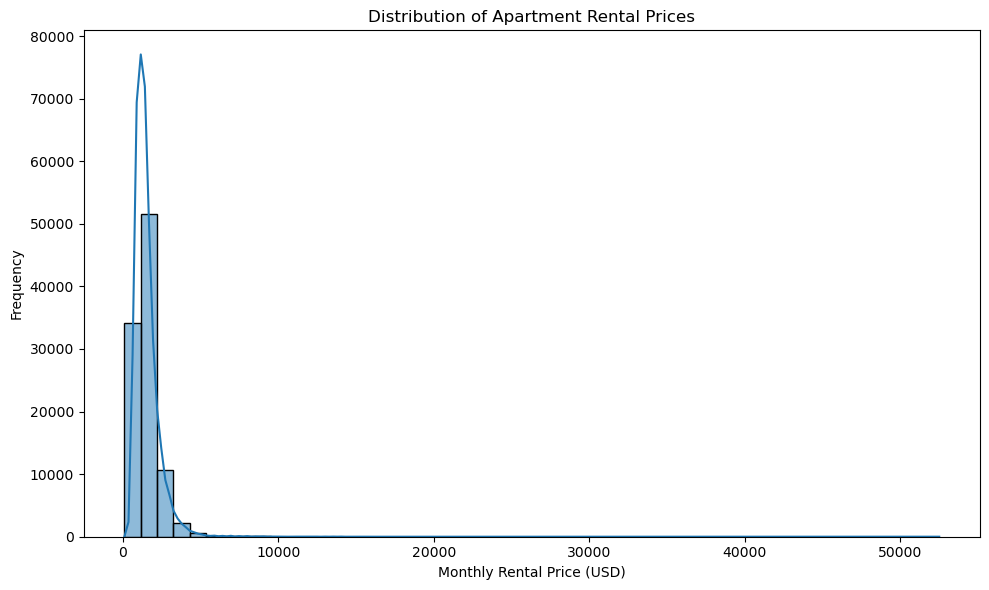

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="price",
    bins=50,
    kde=True
)

plt.title("Distribution of Apartment Rental Prices")
plt.xlabel("Monthly Rental Price (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

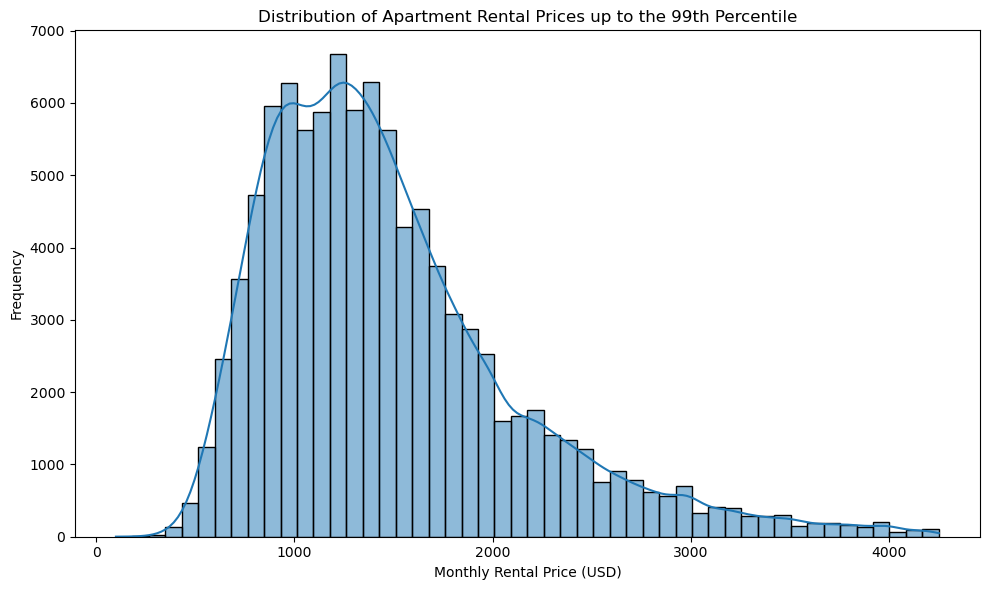

In [14]:
price_99th_percentile = df["price"].quantile(0.99)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df[df["price"] <= price_99th_percentile],
    x="price",
    bins=50,
    kde=True
)

plt.title("Distribution of Apartment Rental Prices up to the 99th Percentile")
plt.xlabel("Monthly Rental Price (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

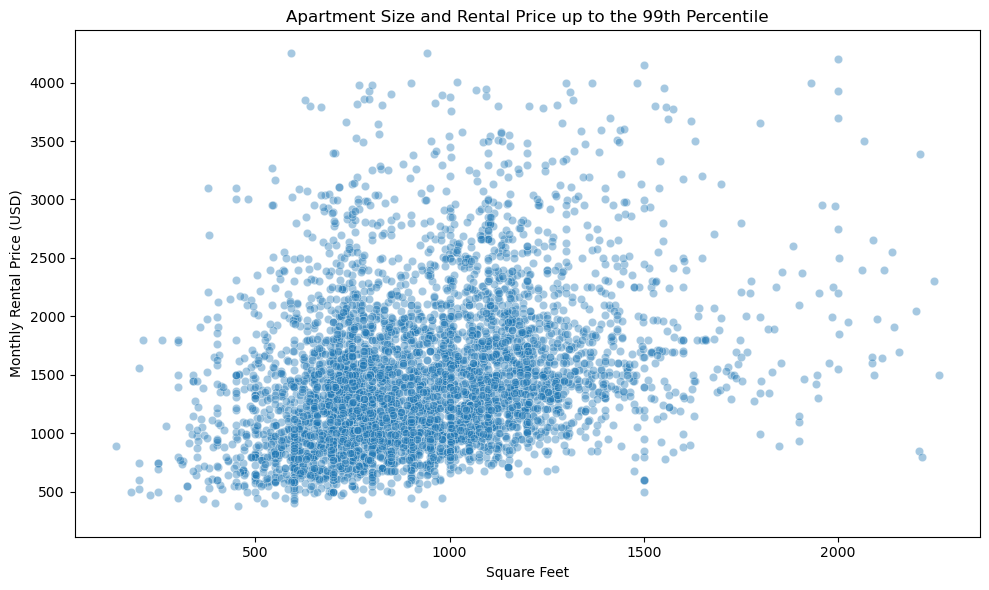

In [15]:
size_limit = df["square_feet"].quantile(0.99)
price_limit = df["price"].quantile(0.99)

plot_data = df[
    (df["square_feet"] <= size_limit) &
    (df["price"] <= price_limit)
]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_data.sample(
        n=min(5000, len(plot_data)),
        random_state=42
    ),
    x="square_feet",
    y="price",
    alpha=0.4
)

plt.title("Apartment Size and Rental Price up to the 99th Percentile")
plt.xlabel("Square Feet")
plt.ylabel("Monthly Rental Price (USD)")
plt.tight_layout()
plt.show()

In [16]:
bedroom_summary = (
    df.groupby("bedrooms")["price"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(bedroom_summary.round(2))

,bedrooms,count,mean,median
0,0.0,662,1402.09,1245.0
1,1.0,40330,1346.85,1216.0
2,2.0,45975,1579.41,1402.0
3,3.0,10561,1791.61,1549.0
4,4.0,1498,2352.24,1845.0
5,5.0,286,3525.06,2625.0
6,6.0,47,8034.57,3200.0
7,7.0,4,14263.75,8350.0
8,8.0,3,5015.00,4000.0
9,9.0,1,3195.00,3195.0


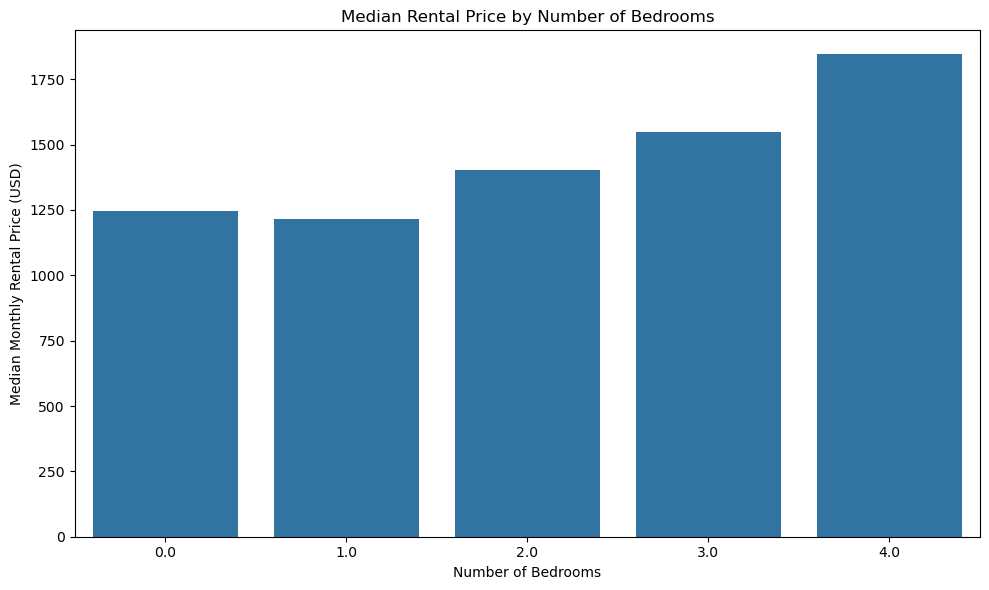

In [17]:
bedroom_plot = bedroom_summary[
    bedroom_summary["count"] >= 500
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=bedroom_plot,
    x="bedrooms",
    y="median"
)

plt.title("Median Rental Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Median Monthly Rental Price (USD)")
plt.tight_layout()
plt.show()

In [18]:
top_5_states = df["state"].value_counts().head(5).index

top_5_state_prices = (
    df[df["state"].isin(top_5_states)]
    .groupby("state")["price"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

top_5_state_prices.columns = [
    "State",
    "Median Rental Price"
]

display(top_5_state_prices)

,State,Median Rental Price
0,CA,2195.0
1,CO,1479.0
2,VA,1412.0
3,TX,1140.0
4,NC,1099.0


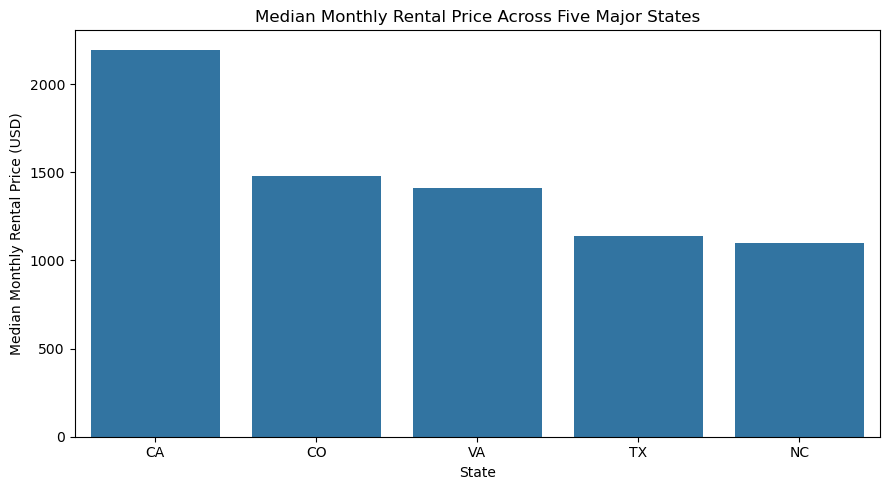

In [19]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=top_5_state_prices,
    x="State",
    y="Median Rental Price"
)

plt.title("Median Monthly Rental Price Across Five Major States")
plt.xlabel("State")
plt.ylabel("Median Monthly Rental Price (USD)")
plt.tight_layout()
plt.show()

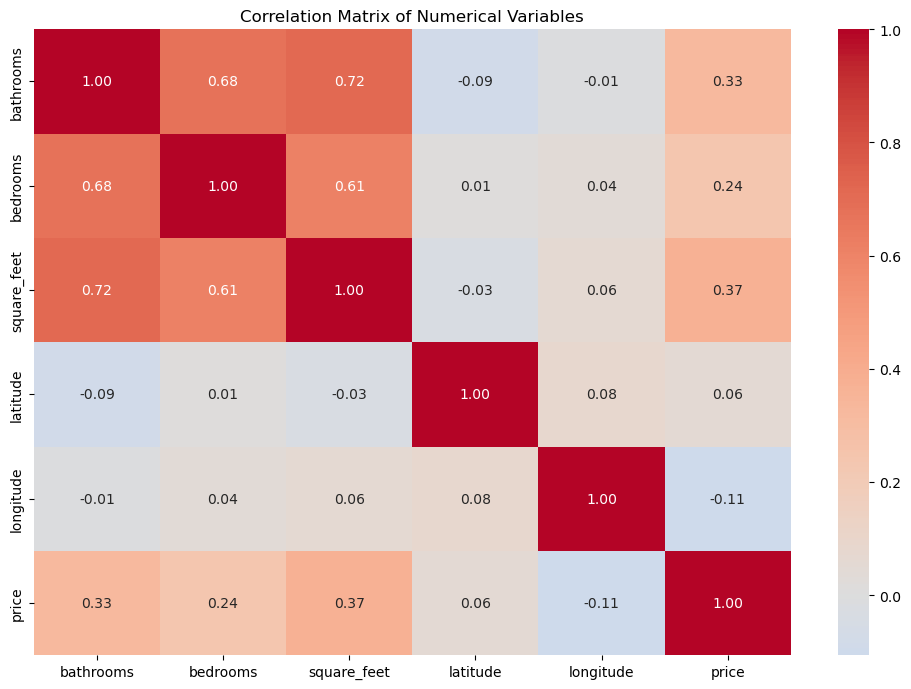

In [20]:
correlation_variables = [
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude",
    "price"
]

correlation_matrix = (
    df[correlation_variables]
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


---


# 3.0 Data Preparation


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [22]:
file_path = "apartments_for_rent_classified_100K.csv"

df = pd.read_csv(
    file_path,
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_clean = df.copy()

print("Original shape:", df_clean.shape)

Original shape: (99492, 22)


In [23]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Correct malformed ID column
if "ï»¿id" in df_clean.columns:
    df_clean = df_clean.rename(columns={"ï»¿id": "id"})

# Correct malformed time column
for column in df_clean.columns:
    if "time" in column.lower():
        df_clean = df_clean.rename(columns={column: "time"})
        break

print("Columns after correction:")
print(df_clean.columns.tolist())

Columns after correction:
['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price', 'price_display', 'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time']


In [24]:
print("Price types before filtering:")
print(df_clean["price_type"].value_counts(dropna=False))

df_clean = df_clean[
    df_clean["price_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("monthly")
].copy()

monthly_rows = len(df_clean)

print("Rows after retaining monthly rentals:", monthly_rows)

Price types before filtering:
price_type
Monthly           99488
Weekly                3
Monthly|Weekly        1
Name: count, dtype: int64
Rows after retaining monthly rentals: 99488


In [25]:
numeric_columns = [
    "price",
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude"
]

for column in numeric_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

print(df_clean[numeric_columns].dtypes)

price          float64
bathrooms      float64
bedrooms       float64
square_feet      int64
latitude       float64
longitude      float64
dtype: object


In [26]:
df_clean = df_clean.dropna(subset=["price"]).copy()

print("Rows after removing missing prices:", len(df_clean))

Rows after removing missing prices: 99487


In [27]:
numeric_fill_columns = [
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude"
]

for column in numeric_fill_columns:
    df_clean[column] = df_clean[column].fillna(
        df_clean[column].median()
    )

print("Missing numerical values:")
print(df_clean[numeric_fill_columns].isna().sum())

Missing numerical values:
bathrooms      0
bedrooms       0
square_feet    0
latitude       0
longitude      0
dtype: int64


In [28]:
df_clean["has_fee"] = (
    df_clean["fee"]
    .fillna("No")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["yes", "true", "1"])
    .astype(int)
)

In [29]:
pets_text = (
    df_clean["pets_allowed"]
    .fillna("")
    .astype(str)
)

df_clean["allows_cats"] = (
    pets_text
    .str.contains("cats", case=False, na=False)
    .astype(int)
)

df_clean["allows_dogs"] = (
    pets_text
    .str.contains("dogs", case=False, na=False)
    .astype(int)
)

In [30]:
amenities_text = (
    df_clean["amenities"]
    .fillna("")
    .astype(str)
)

df_clean["has_pool"] = (
    amenities_text
    .str.contains("pool", case=False, na=False)
    .astype(int)
)

df_clean["has_parking"] = (
    amenities_text
    .str.contains(
        "parking|garage",
        case=False,
        na=False,
        regex=True
    )
    .astype(int)
)

In [31]:
df_clean["has_photo"] = (
    df_clean["has_photo"]
    .fillna("No")
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["yes", "thumbnail", "true", "1"])
    .astype(int)
)

In [32]:
price_condition = (
    df_clean["price"].between(200, 20000)
)

square_feet_condition = (
    df_clean["square_feet"].isna()
    | df_clean["square_feet"].between(100, 10000)
)

df_clean = df_clean[
    price_condition
    & square_feet_condition
].copy()

In [33]:
exact_duplicates = df_clean.duplicated().sum()

print("Exact source duplicates before removal:", exact_duplicates)

df_clean = (
    df_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Rows after removing exact source duplicates:", len(df_clean))

Exact source duplicates before removal: 84
Rows after removing exact source duplicates: 99381


In [34]:
categorical_columns = [
    "category",
    "cityname",
    "state",
    "source"
]

for column in categorical_columns:
    df_clean[column] = (
        df_clean[column]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

print("Missing categorical values:")
print(df_clean[categorical_columns].isna().sum())

Missing categorical values:
category    0
cityname    0
state       0
source      0
dtype: int64


In [35]:
final_columns = [
    "category",
    "bathrooms",
    "bedrooms",
    "has_photo",
    "price",
    "square_feet",
    "cityname",
    "state",
    "latitude",
    "longitude",
    "source",
    "allows_cats",
    "allows_dogs",
    "has_pool",
    "has_parking",
    "has_fee"
]

df_clean = df_clean[final_columns].copy()

print("Final shape:", df_clean.shape)

Final shape: (99381, 16)


In [36]:
final_duplicates = df_clean.duplicated().sum()

print("Duplicate rows in final prepared variables:", final_duplicates)

df_clean = (
    df_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Final shape after duplicate removal:", df_clean.shape)

Duplicate rows in final prepared variables: 9651
Final shape after duplicate removal: (89730, 16)


In [37]:
print("Final dataset shape:", df_clean.shape)
print("\nFinal columns:")
print(df_clean.columns.tolist())

print(
    "\nTotal missing values:",
    df_clean.isna().sum().sum()
)

print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)

print("\nData types:")
print(df_clean.dtypes)

Final dataset shape: (89730, 16)

Final columns:
['category', 'bathrooms', 'bedrooms', 'has_photo', 'price', 'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'source', 'allows_cats', 'allows_dogs', 'has_pool', 'has_parking', 'has_fee']

Total missing values: 0
Duplicate rows: 0

Data types:
category        object
bathrooms      float64
bedrooms       float64
has_photo        int64
price          float64
square_feet      int64
cityname        object
state           object
latitude       float64
longitude      float64
source          object
allows_cats      int64
allows_dogs      int64
has_pool         int64
has_parking      int64
has_fee          int64
dtype: object


In [38]:
range_columns = [
    "price",
    "square_feet",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude"
]

print(df_clean[range_columns].agg(["min", "max"]))

       price  square_feet  bedrooms  bathrooms  latitude  longitude
min    200.0          101       0.0        1.0   19.5738  -159.3698
max  20000.0         9998       9.0        7.0   64.8332   -68.7788


In [39]:
output_path = Path("apartments_prepared.csv")

df_clean.to_csv(
    output_path,
    index=False,
    encoding="utf-8"
)

print("Dataset saved as:", output_path)

Dataset saved as: apartments_prepared.csv


In [40]:
test_df = pd.read_csv("apartments_prepared.csv")

print("Saved dataset shape:", test_df.shape)
print("Saved columns:", test_df.columns.tolist())
print(
    "Saved missing values:",
    test_df.isna().sum().sum()
)
print(
    "Saved duplicate rows:",
    test_df.duplicated().sum()
)

Saved dataset shape: (89730, 16)
Saved columns: ['category', 'bathrooms', 'bedrooms', 'has_photo', 'price', 'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'source', 'allows_cats', 'allows_dogs', 'has_pool', 'has_parking', 'has_fee']
Saved missing values: 0
Saved duplicate rows: 0


In [41]:
print("Final dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isna().sum().sum())
print("Final columns:", df_clean.columns.tolist())

print(
    "Repeated modelling-variable combinations:",
    df_clean.duplicated().sum()
)

Final dataset shape: (89730, 16)
Missing values: 0
Final columns: ['category', 'bathrooms', 'bedrooms', 'has_photo', 'price', 'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'source', 'allows_cats', 'allows_dogs', 'has_pool', 'has_parking', 'has_fee']
Repeated modelling-variable combinations: 0


In [42]:
print("Missing values by column:")
print(df_clean.isna().sum())

print(
    "Total missing values:",
    df_clean.isna().sum().sum()
)

Missing values by column:
category       0
bathrooms      0
bedrooms       0
has_photo      0
price          0
square_feet    0
cityname       0
state          0
latitude       0
longitude      0
source         0
allows_cats    0
allows_dogs    0
has_pool       0
has_parking    0
has_fee        0
dtype: int64
Total missing values: 0


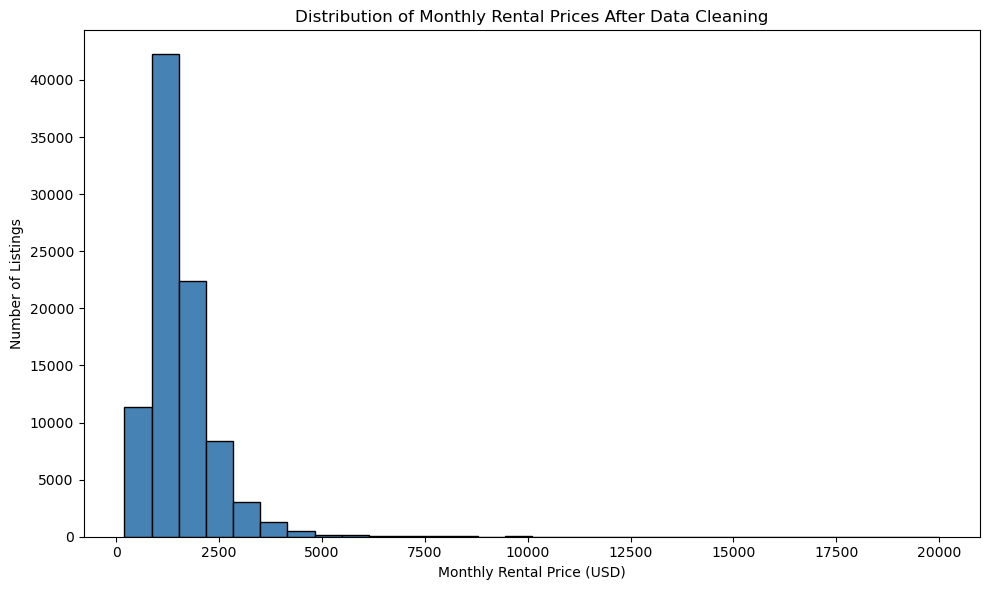

In [43]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_clean["price"].dropna(),
    bins=30,
    edgecolor="black",
    color="steelblue"
)

plt.xlabel("Monthly Rental Price (USD)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Monthly Rental Prices After Data Cleaning")

plt.tight_layout()
plt.show()

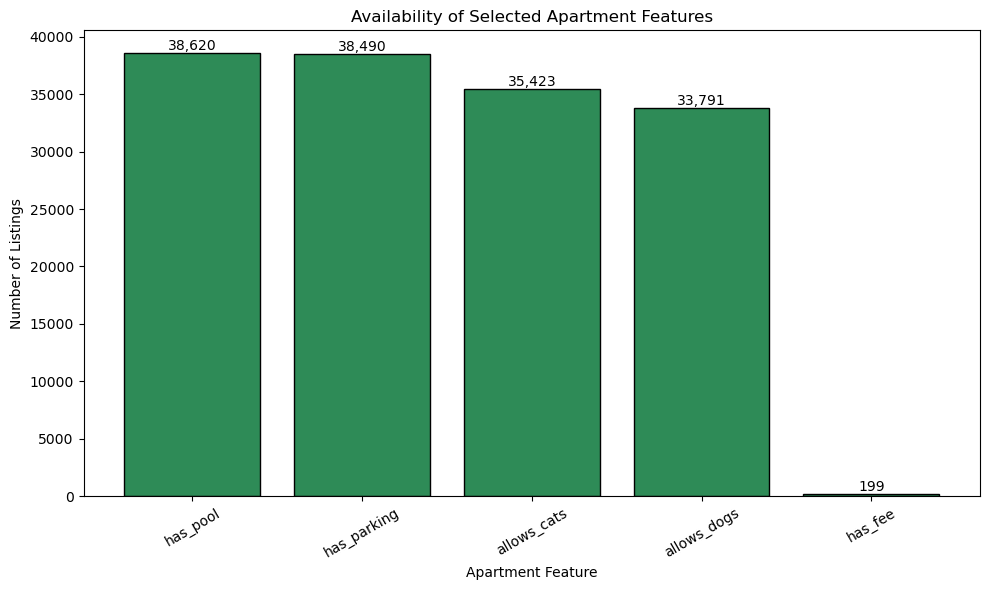

In [44]:
features = [
    "allows_cats",
    "allows_dogs",
    "has_pool",
    "has_parking",
    "has_fee"
]

feature_counts = (
    df_clean[features]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    feature_counts.index,
    feature_counts.values,
    color="seagreen",
    edgecolor="black"
)

plt.xlabel("Apartment Feature")
plt.ylabel("Number of Listings")
plt.title("Availability of Selected Apartment Features")
plt.xticks(rotation=30)

# Display values above the bars
for bar in bars:
    value = int(bar.get_height())

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


---


# 4.1 Linear Regression


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [46]:
df = pd.read_csv("apartments_prepared.csv")

print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.head()

Dataset shape: (89730, 16)
Total missing values: 0
Duplicate rows: 0


,category,bathrooms,bedrooms,has_photo,price,square_feet,cityname,state,latitude,longitude,source,allows_cats,allows_dogs,has_pool,has_parking,has_fee
0,housing/rent/apartment,1.0,1.0,1,2195.0,542,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1,0,0,0,0
1,housing/rent/apartment,1.5,3.0,1,1250.0,1500,Newport News,VA,37.0867,-76.4941,RentLingo,1,1,0,0,0
2,housing/rent/apartment,2.0,3.0,1,1395.0,1650,Raleigh,NC,35.8230,-78.6438,RentLingo,0,0,0,0,0
3,housing/rent/apartment,1.0,2.0,1,1600.0,820,Vacaville,CA,38.3622,-121.9712,RentLingo,1,1,0,0,0
4,housing/rent/apartment,1.0,1.0,1,975.0,624,Albuquerque,NM,35.1038,-106.6110,RentLingo,1,1,0,0,0


In [47]:
features = [
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude",
    "allows_cats",
    "allows_dogs",
    "has_pool",
    "has_parking",
    "has_fee",
    "has_photo",
    "state"
]

target = "price"

X = df[features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (89730, 12)
y shape: (89730,)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 71784
Testing observations: 17946


In [49]:
categorical_features = ["state"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [50]:
linear_regression = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_regression.fit(
    X_train,
    y_train
)

print("Linear Regression model trained successfully.")

# Check final number of features after preprocessing
feature_names = (
    linear_regression
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of features after preprocessing:", len(feature_names))

Linear Regression model trained successfully.
Number of features after preprocessing: 63


In [51]:
# Generate predictions
y_train_pred = linear_regression.predict(X_train)
y_test_pred = linear_regression.predict(X_test)

# MAE
train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

# RMSE
train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

# R²
train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print(f"Training MAE:  USD {train_mae:.2f}")
print(f"Testing MAE:   USD {test_mae:.2f}")
print(f"Training RMSE: USD {train_rmse:.2f}")
print(f"Testing RMSE:  USD {test_rmse:.2f}")
print(f"Training R²:   {train_r2:.4f}")
print(f"Testing R²:    {test_r2:.4f}")

Training MAE:  USD 369.01
Testing MAE:   USD 367.70
Training RMSE: USD 599.08
Testing RMSE:  USD 590.86
Training R²:   0.4816
Testing R²:    0.4899


In [52]:
lr_performance = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "MAE (USD)": [
        train_mae,
        test_mae
    ],
    "RMSE (USD)": [
        train_rmse,
        test_rmse
    ],
    "R²": [
        train_r2,
        test_r2
    ]
})

lr_performance["MAE (USD)"] = (
    lr_performance["MAE (USD)"].round(2)
)

lr_performance["RMSE (USD)"] = (
    lr_performance["RMSE (USD)"].round(2)
)

lr_performance["R²"] = (
    lr_performance["R²"].round(4)
)

lr_performance

,Dataset,MAE (USD),RMSE (USD),R²
0,Training,369.01,599.08,0.4816
1,Testing,367.70,590.86,0.4899


In [53]:
lr_performance = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "MAE (USD)": [
        train_mae,
        test_mae
    ],
    "RMSE (USD)": [
        train_rmse,
        test_rmse
    ],
    "R²": [
        train_r2,
        test_r2
    ]
})

lr_performance["MAE (USD)"] = (
    lr_performance["MAE (USD)"].round(2)
)

lr_performance["RMSE (USD)"] = (
    lr_performance["RMSE (USD)"].round(2)
)

lr_performance["R²"] = (
    lr_performance["R²"].round(4)
)

lr_performance

,Dataset,MAE (USD),RMSE (USD),R²
0,Training,369.01,599.08,0.4816
1,Testing,367.70,590.86,0.4899


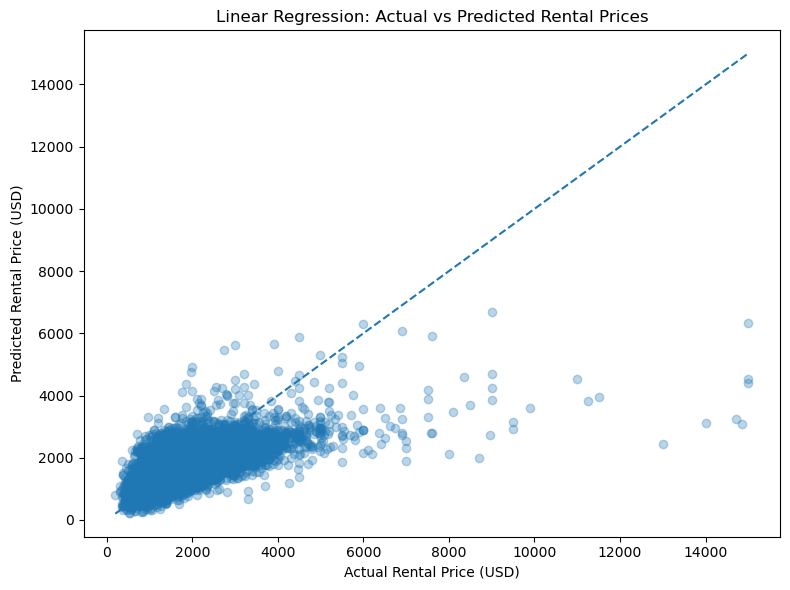

In [54]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.3
)

minimum = min(
    y_test.min(),
    y_test_pred.min()
)

maximum = max(
    y_test.max(),
    y_test_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Rental Price (USD)")
plt.ylabel("Predicted Rental Price (USD)")
plt.title(
    "Linear Regression: Actual vs Predicted Rental Prices"
)

plt.tight_layout()
plt.show()

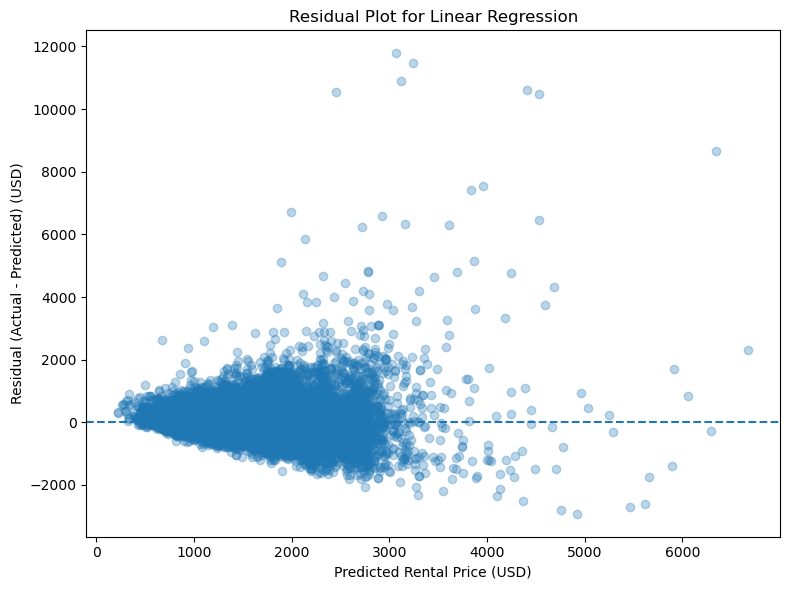

In [55]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Rental Price (USD)")
plt.ylabel("Residual (Actual - Predicted) (USD)")
plt.title(
    "Residual Plot for Linear Regression"
)

plt.tight_layout()
plt.show()


---


# 4.2 Decision Tree Regressor


In [56]:
# =========================================================
# 4.2 DECISION TREE REGRESSOR
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------------------------------------
# 1. Load prepared dataset
# ---------------------------------------------------------

df = pd.read_csv("apartments_prepared.csv")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Dataset shape: (89730, 16)
                 category  bathrooms  bedrooms  has_photo   price  \
0  housing/rent/apartment        1.0       1.0          1  2195.0   
1  housing/rent/apartment        1.5       3.0          1  1250.0   
2  housing/rent/apartment        2.0       3.0          1  1395.0   
3  housing/rent/apartment        1.0       2.0          1  1600.0   
4  housing/rent/apartment        1.0       1.0          1   975.0   

   square_feet       cityname state  latitude  longitude     source  \
0          542  Redondo Beach    CA   33.8520  -118.3759  RentLingo   
1         1500   Newport News    VA   37.0867   -76.4941  RentLingo   
2         1650        Raleigh    NC   35.8230   -78.6438  RentLingo   
3          820      Vacaville    CA   38.3622  -121.9712  RentLingo   
4          624    Albuquerque    NM   35.1038  -106.6110  RentLingo   

   allows_cats  allows_dogs  has_pool  has_parking  has_fee  
0            1            0         0            0        0  
1      

In [57]:
# ---------------------------------------------------------
# 2. Select predictors and target
# ---------------------------------------------------------

features = [
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude",
    "allows_cats",
    "allows_dogs",
    "has_pool",
    "has_parking",
    "has_fee",
    "has_photo",
    "state"
]

X = df[features]
y = df["price"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

Predictor shape: (89730, 12)
Target shape: (89730,)


In [58]:
# ---------------------------------------------------------
# 3. Define numerical and categorical predictors
# ---------------------------------------------------------

numerical_features = [
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude",
    "allows_cats",
    "allows_dogs",
    "has_pool",
    "has_parking",
    "has_fee"
]

categorical_features = [
    "has_photo",
    "state"
]

In [59]:
# ---------------------------------------------------------
# 4. Train-test split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 71784
Testing observations: 17946


In [60]:
# ---------------------------------------------------------
# 5. Preprocessing
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [61]:
# ---------------------------------------------------------
# 6. Baseline Decision Tree
# ---------------------------------------------------------

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Baseline Decision Tree Results")
print("--------------------------------")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²:", round(baseline_r2, 4))

Baseline Decision Tree Results
--------------------------------
MAE: 233.92
RMSE: 490.21
R²: 0.6489


In [62]:
# ---------------------------------------------------------
# 7. Hyperparameter tuning
# ---------------------------------------------------------

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

param_grid = {
    "regressor__max_depth": [
        6, 8, 10, 12, 15, 20
    ],
    "regressor__min_samples_split": [
        2, 5, 10, 20
    ],
    "regressor__min_samples_leaf": [
        5, 10, 20, 25, 50
    ]
}

grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "Best Cross-Validation RMSE:",
    round(-grid_search.best_score_, 2)
)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Parameters:
{'regressor__max_depth': 20, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 20}
Best Cross-Validation RMSE: 436.02


In [63]:
# ---------------------------------------------------------
# 8. Best tuned model
# ---------------------------------------------------------

best_dt_pipeline = grid_search.best_estimator_

In [64]:
# ---------------------------------------------------------
# 9. Training performance
# ---------------------------------------------------------

y_train_pred = best_dt_pipeline.predict(X_train)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

print("Training Performance")
print("--------------------")
print("Training MAE:", round(train_mae, 2))
print("Training RMSE:", round(train_rmse, 2))
print("Training R²:", round(train_r2, 4))

Training Performance
--------------------
Training MAE: 188.75
Training RMSE: 328.3
Training R²: 0.8443


In [65]:
# ---------------------------------------------------------
# 10. Testing performance
# ---------------------------------------------------------

y_test_pred = best_dt_pipeline.predict(X_test)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("Testing Performance")
print("-------------------")
print("Testing MAE:", round(test_mae, 2))
print("Testing RMSE:", round(test_rmse, 2))
print("Testing R²:", round(test_r2, 4))

Testing Performance
-------------------
Testing MAE: 235.97
Testing RMSE: 438.24
Testing R²: 0.7194


In [66]:
# ---------------------------------------------------------
# 11. Training-testing comparison
# ---------------------------------------------------------

performance_table = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "Training": [
        train_mae,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mae,
        test_rmse,
        test_r2
    ]
})

performance_table["Difference"] = (
    performance_table["Testing"]
    - performance_table["Training"]
)

performance_table = performance_table.round(4)

print("Decision Tree Regressor Performance")
display(performance_table)

Decision Tree Regressor Performance


,Metric,Training,Testing,Difference
0,MAE,188.7506,235.9677,47.2171
1,RMSE,328.3039,438.2397,109.9357
2,R²,0.8443,0.7194,-0.1249


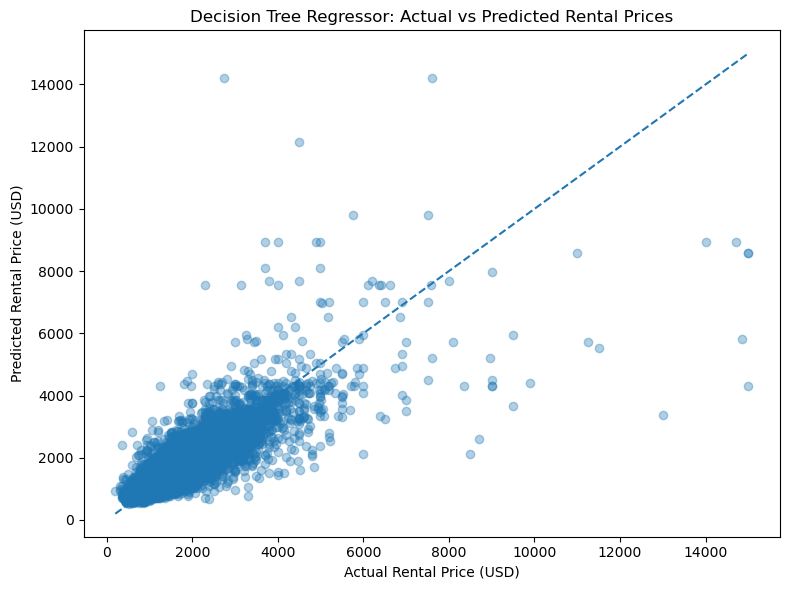

In [67]:
# ---------------------------------------------------------
# 12. Actual vs Predicted
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.35
)

minimum = min(
    y_test.min(),
    y_test_pred.min()
)

maximum = max(
    y_test.max(),
    y_test_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Rental Price (USD)")
plt.ylabel("Predicted Rental Price (USD)")
plt.title(
    "Decision Tree Regressor: Actual vs Predicted Rental Prices"
)

plt.tight_layout()
plt.show()

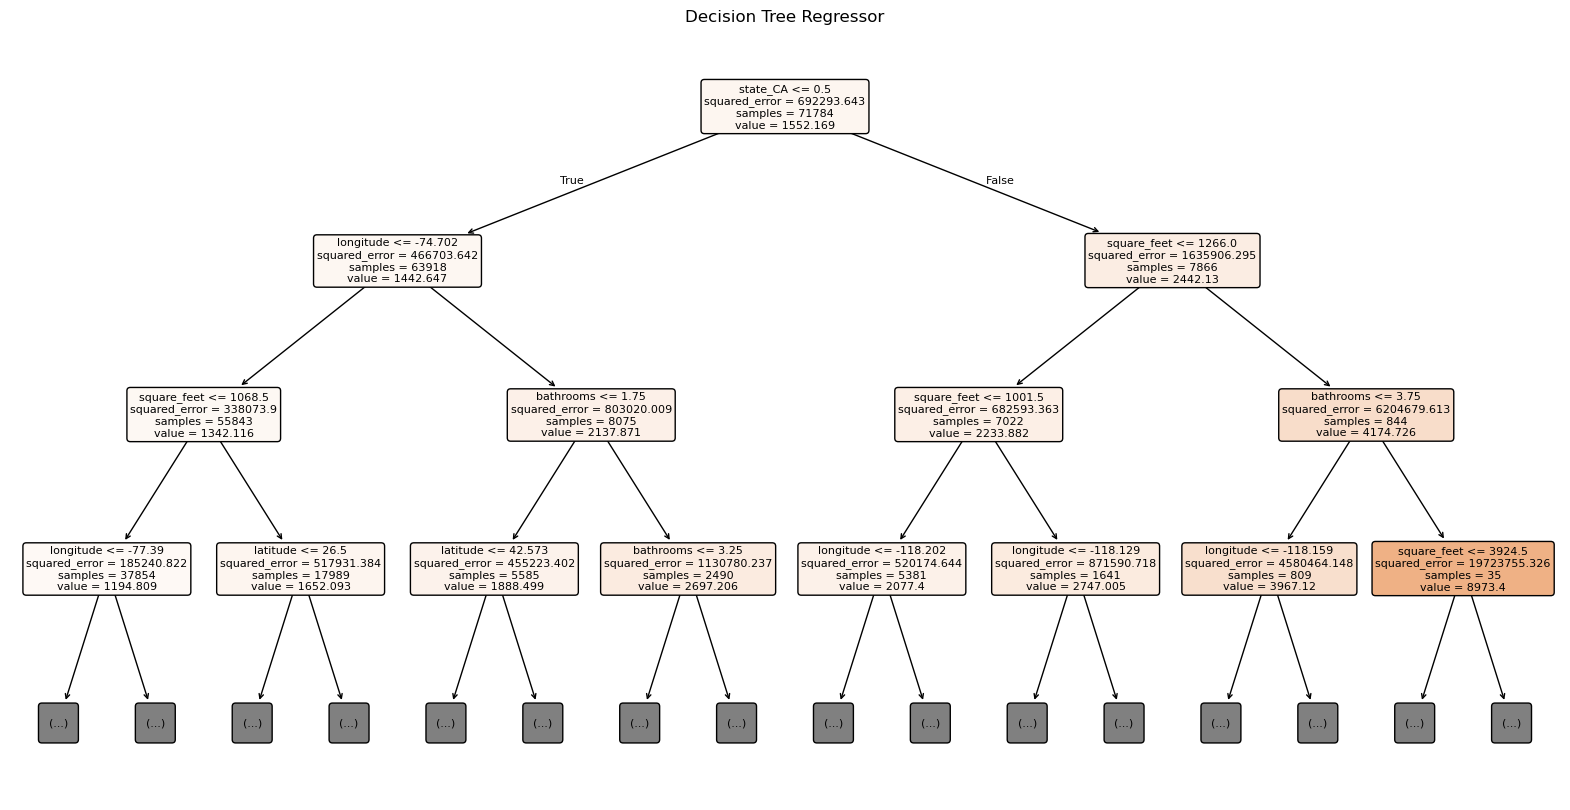

In [68]:
# ---------------------------------------------------------
# 13. Decision Tree visualization
# ---------------------------------------------------------

fitted_preprocessor = (
    best_dt_pipeline.named_steps["preprocessor"]
)

fitted_tree = (
    best_dt_pipeline.named_steps["regressor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

clean_feature_names = [
    name.replace("cat__", "")
        .replace("remainder__", "")
    for name in feature_names
]

plt.figure(figsize=(20, 10))

plot_tree(
    fitted_tree,
    feature_names=clean_feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Regressor")
plt.show()

In [69]:
# ---------------------------------------------------------
# 14. Feature importance
# ---------------------------------------------------------

importance_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Importance": fitted_tree.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(10)
)

print(importance_df)

        Feature  Importance
58    longitude    0.266729
56  square_feet    0.256696
57     latitude    0.178479
6      state_CA    0.166755
54    bathrooms    0.064554
7      state_CO    0.010164
50     state_WA    0.009438
55     bedrooms    0.008846
36     state_NY    0.007934
61     has_pool    0.005451


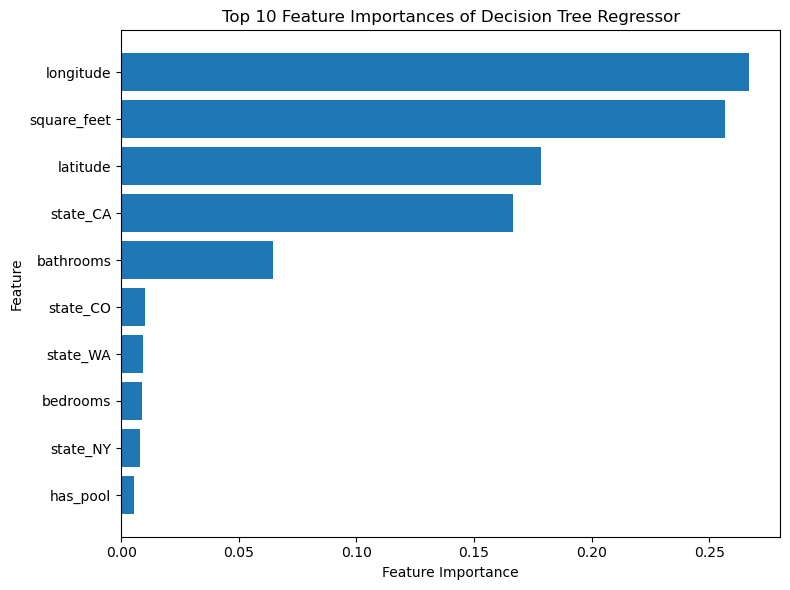

In [70]:
plot_df = importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 10 Feature Importances of Decision Tree Regressor"
)

plt.tight_layout()
plt.show()


---


# 4.3 Random Forest Regressor


In [71]:
import pandas as pd
import numpy as np

df = pd.read_csv("apartments_prepared.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (89730, 16)


,category,bathrooms,bedrooms,has_photo,price,square_feet,cityname,state,latitude,longitude,source,allows_cats,allows_dogs,has_pool,has_parking,has_fee
0,housing/rent/apartment,1.0,1.0,1,2195.0,542,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1,0,0,0,0
1,housing/rent/apartment,1.5,3.0,1,1250.0,1500,Newport News,VA,37.0867,-76.4941,RentLingo,1,1,0,0,0
2,housing/rent/apartment,2.0,3.0,1,1395.0,1650,Raleigh,NC,35.8230,-78.6438,RentLingo,0,0,0,0,0
3,housing/rent/apartment,1.0,2.0,1,1600.0,820,Vacaville,CA,38.3622,-121.9712,RentLingo,1,1,0,0,0
4,housing/rent/apartment,1.0,1.0,1,975.0,624,Albuquerque,NM,35.1038,-106.6110,RentLingo,1,1,0,0,0


In [72]:
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

category        object
bathrooms      float64
bedrooms       float64
has_photo        int64
price          float64
square_feet      int64
cityname        object
state           object
latitude       float64
longitude      float64
source          object
allows_cats      int64
allows_dogs      int64
has_pool         int64
has_parking      int64
has_fee          int64
dtype: object

Missing values:
category       0
bathrooms      0
bedrooms       0
has_photo      0
price          0
square_feet    0
cityname       0
state          0
latitude       0
longitude      0
source         0
allows_cats    0
allows_dogs    0
has_pool       0
has_parking    0
has_fee        0
dtype: int64


In [73]:
features = [
    'bathrooms',
    'bedrooms',
    'square_feet',
    'latitude',
    'longitude',
    'has_photo',
    'allows_cats',
    'allows_dogs',
    'has_pool',
    'has_parking',
    'has_fee',
    'state'
]

X = df[features].copy()
y = df['price'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (89730, 12)
y shape: (89730,)


,bathrooms,bedrooms,square_feet,latitude,longitude,has_photo,allows_cats,allows_dogs,has_pool,has_parking,has_fee,state
0,1.0,1.0,542,33.8520,-118.3759,1,1,0,0,0,0,CA
1,1.5,3.0,1500,37.0867,-76.4941,1,1,1,0,0,0,VA
2,2.0,3.0,1650,35.8230,-78.6438,1,0,0,0,0,0,NC
3,1.0,2.0,820,38.3622,-121.9712,1,1,1,0,0,0,CA
4,1.0,1.0,624,35.1038,-106.6110,1,1,1,0,0,0,NM


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (71784, 12)
X_test: (17946, 12)
y_train: (71784,)
y_test: (17946,)


In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'state'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

In [77]:
rf_param_grid = {
    'regressor__n_estimators': [100],
    'regressor__max_depth': [10, 20],
    'regressor__max_features': ['sqrt'],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

In [78]:
from sklearn.model_selection import GridSearchCV

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=2
)

rf_grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regressor__max_depth': [10, 20], 'regressor__max_features': ['sqrt'], 'regressor__min_samples_leaf': [1, 2], 'regressor__min_samples_split': [2, 5], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...)]"


In [79]:
print("Best Parameters:")
print(rf_grid_search.best_params_)

rf_cv_rmse = np.sqrt(
    -rf_grid_search.best_score_
)

print(
    "Best Cross-Validation RMSE:",
    round(rf_cv_rmse, 2)
)

Best Parameters:
{'regressor__max_depth': 20, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
Best Cross-Validation RMSE: 424.46


In [80]:
best_params = {
    key.replace('regressor__', ''): value
    for key, value in rf_grid_search.best_params_.items()
}

rf_best_parameters = pd.DataFrame(
    list(best_params.items()),
    columns=['Parameter', 'Best Value']
)

rf_best_parameters

,Parameter,Best Value
0,max_depth,20
1,max_features,sqrt
2,min_samples_leaf,1
3,min_samples_split,2
4,n_estimators,100


In [81]:
best_rf_model = rf_grid_search.best_estimator_

rf_train_pred = best_rf_model.predict(X_train)
rf_test_pred = best_rf_model.predict(X_test)

In [82]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Training
rf_train_mae = mean_absolute_error(
    y_train,
    rf_train_pred
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        rf_train_pred
    )
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_pred
)

# Testing
rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)

rf_performance = pd.DataFrame({
    'Dataset': ['Training', 'Testing'],
    'MAE': [rf_train_mae, rf_test_mae],
    'RMSE': [rf_train_rmse, rf_test_rmse],
    'R²': [rf_train_r2, rf_test_r2]
})

rf_performance.round(4)

,Dataset,MAE,RMSE,R²
0,Training,192.6502,285.8536,0.8820
1,Testing,245.2425,412.3176,0.7516


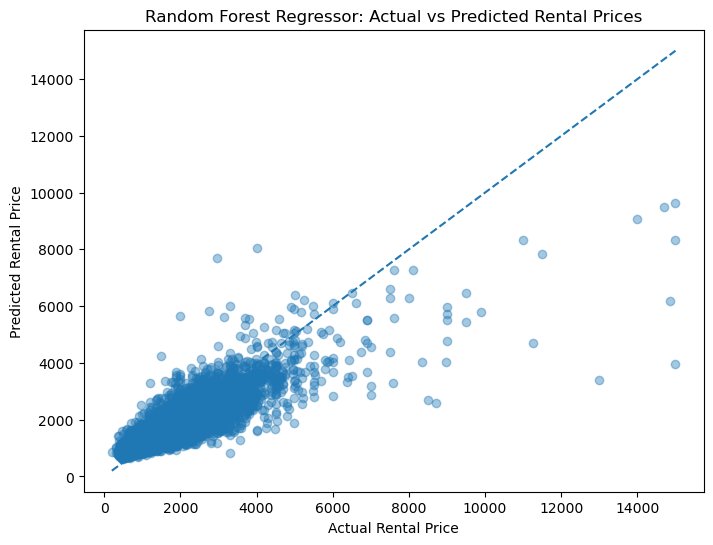

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_test_pred,
    alpha=0.4
)

min_price = min(
    y_test.min(),
    rf_test_pred.min()
)

max_price = max(
    y_test.max(),
    rf_test_pred.max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel('Actual Rental Price')
plt.ylabel('Predicted Rental Price')

plt.title(
    'Random Forest Regressor: '
    'Actual vs Predicted Rental Prices'
)

plt.show()

In [84]:
feature_names = (
    best_rf_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

rf_regressor = (
    best_rf_model
    .named_steps['regressor']
)

rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_regressor.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

rf_top_features = rf_feature_importance.head(10)

rf_top_features

,Feature,Importance
56,remainder__longitude,0.241843
54,remainder__square_feet,0.188156
55,remainder__latitude,0.160362
4,cat__state_CA,0.100730
52,remainder__bathrooms,0.097110
53,remainder__bedrooms,0.048531
19,cat__state_MA,0.029277
31,cat__state_NJ,0.016468
60,remainder__has_pool,0.011841
34,cat__state_NY,0.011127


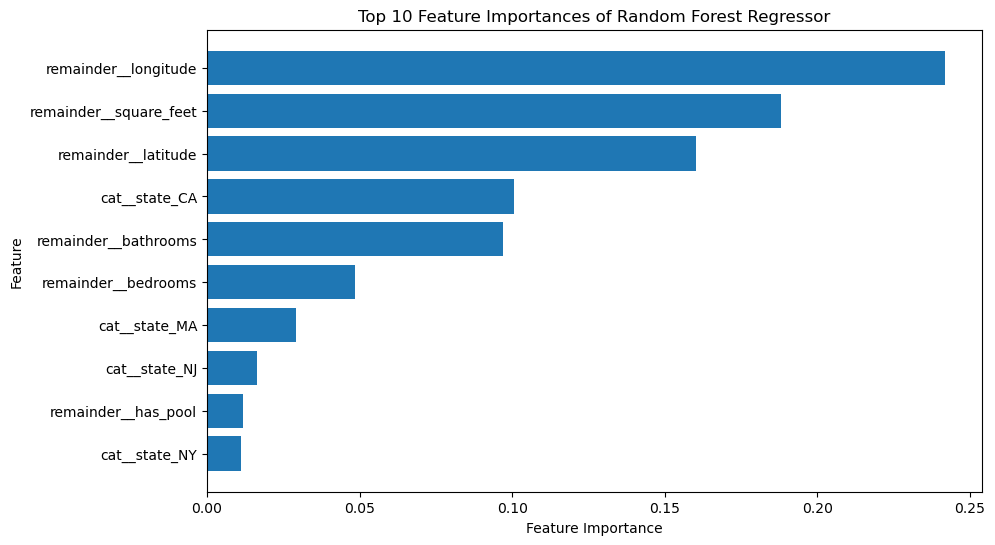

In [85]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_top_features['Feature'],
    rf_top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.title(
    'Top 10 Feature Importances '
    'of Random Forest Regressor'
)

plt.gca().invert_yaxis()

plt.show()

In [86]:
feature_names = (
    best_rf_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

rf_regressor = (
    best_rf_model
    .named_steps['regressor']
)

rf_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_regressor.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        by='Importance',
        ascending=False
    )
)

rf_top_features = rf_feature_importance.head(10)

rf_top_features

,Feature,Importance
56,remainder__longitude,0.241843
54,remainder__square_feet,0.188156
55,remainder__latitude,0.160362
4,cat__state_CA,0.100730
52,remainder__bathrooms,0.097110
53,remainder__bedrooms,0.048531
19,cat__state_MA,0.029277
31,cat__state_NJ,0.016468
60,remainder__has_pool,0.011841
34,cat__state_NY,0.011127


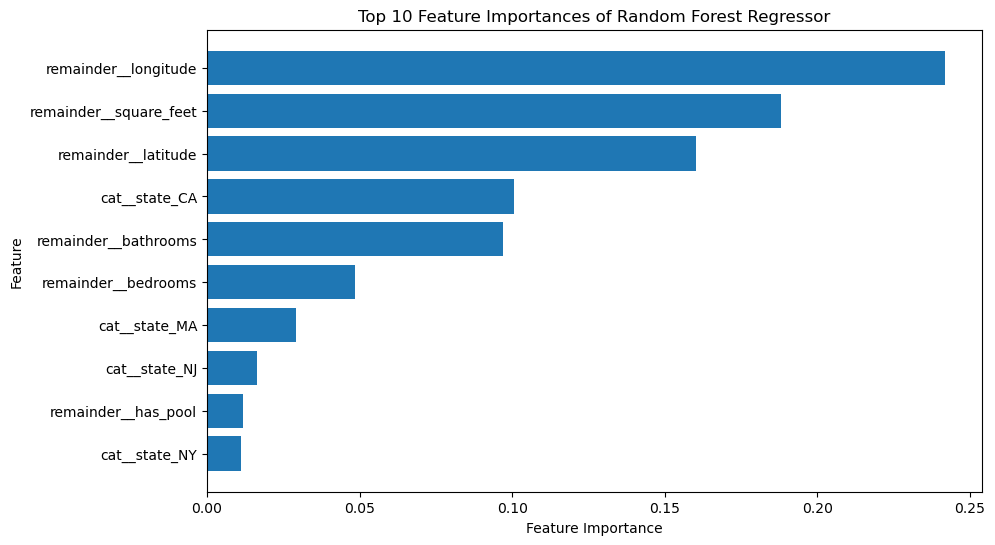

In [87]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_top_features['Feature'],
    rf_top_features['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title(
    'Top 10 Feature Importances of Random Forest Regressor'
)

plt.gca().invert_yaxis()

plt.show()

In [88]:
import joblib

joblib.dump(
    best_rf_model,
    "random_forest_rent_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!



---


# 4.4 Gradient Boosting Regressor


In [89]:
# =========================================================
# 4.4 GRADIENT BOOSTING REGRESSOR
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [90]:
# =========================================================
# 1. LOAD PREPARED DATASET
# =========================================================

file_path = "apartments_prepared.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully.
Dataset shape: (89730, 16)

Columns:
['category', 'bathrooms', 'bedrooms', 'has_photo', 'price', 'square_feet', 'cityname', 'state', 'latitude', 'longitude', 'source', 'allows_cats', 'allows_dogs', 'has_pool', 'has_parking', 'has_fee']


,category,bathrooms,bedrooms,has_photo,price,square_feet,cityname,state,latitude,longitude,source,allows_cats,allows_dogs,has_pool,has_parking,has_fee
0,housing/rent/apartment,1.0,1.0,1,2195.0,542,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1,0,0,0,0
1,housing/rent/apartment,1.5,3.0,1,1250.0,1500,Newport News,VA,37.0867,-76.4941,RentLingo,1,1,0,0,0
2,housing/rent/apartment,2.0,3.0,1,1395.0,1650,Raleigh,NC,35.8230,-78.6438,RentLingo,0,0,0,0,0
3,housing/rent/apartment,1.0,2.0,1,1600.0,820,Vacaville,CA,38.3622,-121.9712,RentLingo,1,1,0,0,0
4,housing/rent/apartment,1.0,1.0,1,975.0,624,Albuquerque,NM,35.1038,-106.6110,RentLingo,1,1,0,0,0


In [91]:
# =========================================================
# 2. CHECK DATASET QUALITY
# =========================================================

print("Dataset Information:")
df.info()

print("\nTotal missing values:")
print(df.isnull().sum().sum())

print("\nMissing values by column:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89730 entries, 0 to 89729
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category     89730 non-null  object 
 1   bathrooms    89730 non-null  float64
 2   bedrooms     89730 non-null  float64
 3   has_photo    89730 non-null  int64  
 4   price        89730 non-null  float64
 5   square_feet  89730 non-null  int64  
 6   cityname     89730 non-null  object 
 7   state        89730 non-null  object 
 8   latitude     89730 non-null  float64
 9   longitude    89730 non-null  float64
 10  source       89730 non-null  object 
 11  allows_cats  89730 non-null  int64  
 12  allows_dogs  89730 non-null  int64  
 13  has_pool     89730 non-null  int64  
 14  has_parking  89730 non-null  int64  
 15  has_fee      89730 non-null  int64  
dtypes: float64(5), int64(7), object(4)
memory usage: 11.0+ MB

Total missing values:
0

Missing values by column:

In [92]:
# =========================================================
# 3. SELECT PREDICTORS AND TARGET
# =========================================================

features = [
    "bathrooms",
    "bedrooms",
    "square_feet",
    "latitude",
    "longitude",
    "allows_cats",
    "allows_dogs",
    "has_pool",
    "has_parking",
    "has_fee",
    "has_photo",
    "state"
]

target = "price"

X = df[features].copy()
y = df[target].copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)

print("\nSelected predictors:")
print(X.columns.tolist())

Predictor shape: (89730, 12)
Target shape: (89730,)

Selected predictors:
['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude', 'allows_cats', 'allows_dogs', 'has_pool', 'has_parking', 'has_fee', 'has_photo', 'state']


In [93]:
# =========================================================
# 4. TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (71784, 12)
X_test shape: (17946, 12)
y_train shape: (71784,)
y_test shape: (17946,)


In [94]:
# =========================================================
# 5. PREPROCESSING
# =========================================================

categorical_features = ["state"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [95]:
# =========================================================
# 6. BASELINE GRADIENT BOOSTING MODEL
# =========================================================

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

baseline_pipeline.fit(X_train, y_train)

print("Baseline Gradient Boosting model trained successfully.")

Baseline Gradient Boosting model trained successfully.


In [96]:
# =========================================================
# 7. BASELINE MODEL EVALUATION
# =========================================================

baseline_train_predictions = baseline_pipeline.predict(X_train)
baseline_test_predictions = baseline_pipeline.predict(X_test)

baseline_train_mae = mean_absolute_error(
    y_train,
    baseline_train_predictions
)

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_predictions
)

baseline_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        baseline_train_predictions
    )
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_predictions
    )
)

baseline_train_r2 = r2_score(
    y_train,
    baseline_train_predictions
)

baseline_test_r2 = r2_score(
    y_test,
    baseline_test_predictions
)

print("Baseline Gradient Boosting Performance")
print("--------------------------------------")
print(f"Training MAE:  USD {baseline_train_mae:.2f}")
print(f"Testing MAE:   USD {baseline_test_mae:.2f}")
print(f"Training RMSE: USD {baseline_train_rmse:.2f}")
print(f"Testing RMSE:  USD {baseline_test_rmse:.2f}")
print(f"Training R²:   {baseline_train_r2:.4f}")
print(f"Testing R²:    {baseline_test_r2:.4f}")

Baseline Gradient Boosting Performance
--------------------------------------
Training MAE:  USD 302.09
Testing MAE:   USD 303.90
Training RMSE: USD 468.94
Testing RMSE:  USD 484.35
Training R²:   0.6823
Testing R²:    0.6572


In [97]:
# =========================================================
# 8. HYPERPARAMETER SEARCH SPACE
# =========================================================

param_distributions = {
    "regressor__n_estimators": [
        100,
        150,
        200,
        250
    ],
    "regressor__learning_rate": [
        0.03,
        0.05,
        0.10
    ],
    "regressor__max_depth": [
        2,
        3,
        4
    ],
    "regressor__min_samples_split": [
        2,
        5,
        10
    ],
    "regressor__min_samples_leaf": [
        1,
        2,
        4
    ],
    "regressor__subsample": [
        0.8,
        0.9,
        1.0
    ]
}

In [98]:
# =========================================================
# 9. CREATE TUNING PIPELINE
# =========================================================

gbr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

In [99]:
# =========================================================
# 10. HYPERPARAMETER TUNING
# =========================================================

random_search = RandomizedSearchCV(
    estimator=gbr_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=2,
    refit=True
)

random_search.fit(X_train, y_train)

print("\nHyperparameter tuning completed.")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END regressor__learning_rate=0.1, regressor__max_depth=3, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=250, regressor__subsample=1.0; total time=  57.4s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=3, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=250, regressor__subsample=1.0; total time=  55.2s
[CV] END regressor__learning_rate=0.1, regressor__max_depth=3, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=250, regressor__subsample=1.0; total time=  55.3s
[CV] END regressor__learning_rate=0.03, regressor__max_depth=2, regressor__min_samples_leaf=2, regressor__min_samples_split=10, regressor__n_estimators=250, regressor__subsample=0.9; total time=  34.8s
[CV] END regressor__learning_rate=0.03, regressor__max_depth=2, regressor__min_samples_leaf=2, regressor__min_samples_split=10, regressor

In [100]:
# =========================================================
# 11. BEST PARAMETERS
# =========================================================

best_parameters = {
    key.replace("regressor__", ""): value
    for key, value in random_search.best_params_.items()
}

best_cv_rmse = -random_search.best_score_

print("Best Parameters:")
for parameter, value in best_parameters.items():
    print(f"{parameter}: {value}")

print(
    "\nBest Cross-Validation RMSE:",
    round(best_cv_rmse, 2)
)

Best Parameters:
subsample: 0.9
n_estimators: 200
min_samples_split: 10
min_samples_leaf: 4
max_depth: 4
learning_rate: 0.1

Best Cross-Validation RMSE: 430.47


In [101]:
# =========================================================
# 12. OBTAIN BEST TUNED PIPELINE
# =========================================================

best_gbr_pipeline = random_search.best_estimator_

print("Best tuned Gradient Boosting pipeline obtained.")

Best tuned Gradient Boosting pipeline obtained.


In [102]:
# =========================================================
# 13. TUNED MODEL EVALUATION
# =========================================================

tuned_train_predictions = best_gbr_pipeline.predict(X_train)
tuned_test_predictions = best_gbr_pipeline.predict(X_test)

tuned_train_mae = mean_absolute_error(
    y_train,
    tuned_train_predictions
)

tuned_test_mae = mean_absolute_error(
    y_test,
    tuned_test_predictions
)

tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_train_predictions
    )
)

tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_test_predictions
    )
)

tuned_train_r2 = r2_score(
    y_train,
    tuned_train_predictions
)

tuned_test_r2 = r2_score(
    y_test,
    tuned_test_predictions
)

print("Tuned Gradient Boosting Performance")
print("-----------------------------------")
print(f"Training MAE:  USD {tuned_train_mae:.2f}")
print(f"Testing MAE:   USD {tuned_test_mae:.2f}")
print(f"Training RMSE: USD {tuned_train_rmse:.2f}")
print(f"Testing RMSE:  USD {tuned_test_rmse:.2f}")
print(f"Training R²:   {tuned_train_r2:.4f}")
print(f"Testing R²:    {tuned_test_r2:.4f}")

Tuned Gradient Boosting Performance
-----------------------------------
Training MAE:  USD 254.38
Testing MAE:   USD 259.31
Training RMSE: USD 396.24
Testing RMSE:  USD 428.81
Training R²:   0.7732
Testing R²:    0.7313


In [103]:
# =========================================================
# 14. TRAINING-TESTING PERFORMANCE TABLE
# =========================================================

gbr_performance = pd.DataFrame({
    "Metric": [
        "MAE (USD)",
        "RMSE (USD)",
        "R²"
    ],
    "Training": [
        tuned_train_mae,
        tuned_train_rmse,
        tuned_train_r2
    ],
    "Testing": [
        tuned_test_mae,
        tuned_test_rmse,
        tuned_test_r2
    ]
})

gbr_performance["Difference"] = (
    gbr_performance["Testing"]
    - gbr_performance["Training"]
)

gbr_performance = gbr_performance.round(4)

display(gbr_performance)

,Metric,Training,Testing,Difference
0,MAE (USD),254.3751,259.3124,4.9373
1,RMSE (USD),396.2368,428.8130,32.5763
2,R²,0.7732,0.7313,-0.0419


In [104]:
# =========================================================
# 15. BASELINE VS TUNED MODEL
# =========================================================

baseline_tuned_comparison = pd.DataFrame({
    "Metric": [
        "Testing MAE (USD)",
        "Testing RMSE (USD)",
        "Testing R²"
    ],
    "Baseline": [
        baseline_test_mae,
        baseline_test_rmse,
        baseline_test_r2
    ],
    "Tuned": [
        tuned_test_mae,
        tuned_test_rmse,
        tuned_test_r2
    ]
})

baseline_tuned_comparison["Change"] = (
    baseline_tuned_comparison["Tuned"]
    - baseline_tuned_comparison["Baseline"]
)

baseline_tuned_comparison = (
    baseline_tuned_comparison.round(4)
)

display(baseline_tuned_comparison)

,Metric,Baseline,Tuned,Change
0,Testing MAE (USD),303.9033,259.3124,-44.5910
1,Testing RMSE (USD),484.3450,428.8130,-55.5320
2,Testing R²,0.6572,0.7313,0.0741


In [105]:
# =========================================================
# 16. FINAL FEATURE COUNT
# =========================================================

fitted_preprocessor = (
    best_gbr_pipeline.named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor.get_feature_names_out()
)

clean_feature_names = [
    name.replace("categorical__", "")
        .replace("remainder__", "")
    for name in feature_names
]

print(
    "Number of features after preprocessing:",
    len(clean_feature_names)
)

print("\nFeatures after preprocessing:")
print(clean_feature_names)

Number of features after preprocessing: 63

Features after preprocessing:
['state_AK', 'state_AL', 'state_AR', 'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 'state_GA', 'state_HI', 'state_IA', 'state_ID', 'state_IL', 'state_IN', 'state_KS', 'state_KY', 'state_LA', 'state_MA', 'state_MD', 'state_ME', 'state_MI', 'state_MN', 'state_MO', 'state_MS', 'state_MT', 'state_NC', 'state_ND', 'state_NE', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY', 'state_OH', 'state_OK', 'state_OR', 'state_PA', 'state_RI', 'state_SC', 'state_SD', 'state_TN', 'state_TX', 'state_UT', 'state_Unknown', 'state_VA', 'state_VT', 'state_WA', 'state_WI', 'state_WV', 'state_WY', 'bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude', 'allows_cats', 'allows_dogs', 'has_pool', 'has_parking', 'has_fee', 'has_photo']


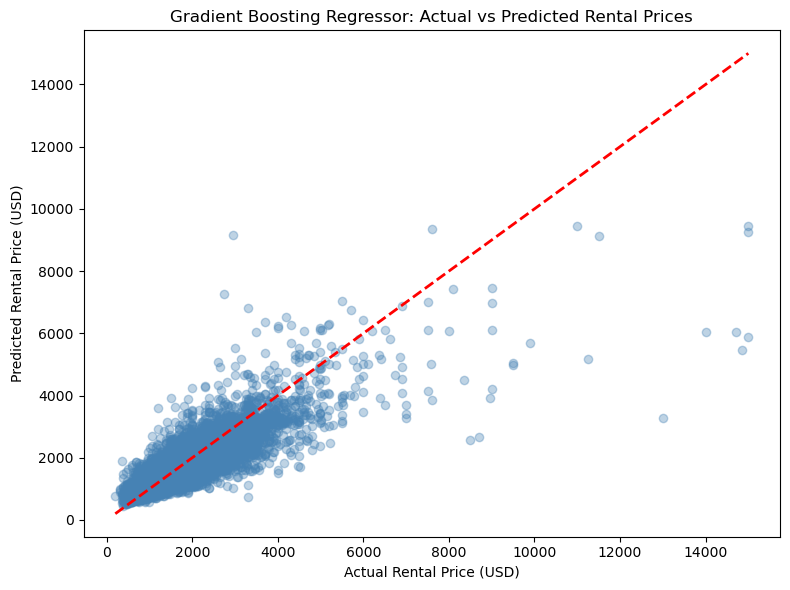

In [106]:
# =========================================================
# 17. ACTUAL VS PREDICTED PLOT
# =========================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    tuned_test_predictions,
    alpha=0.35,
    color="steelblue"
)

minimum_value = min(
    y_test.min(),
    tuned_test_predictions.min()
)

maximum_value = max(
    y_test.max(),
    tuned_test_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    linewidth=2
)

plt.xlabel("Actual Rental Price (USD)")
plt.ylabel("Predicted Rental Price (USD)")
plt.title(
    "Gradient Boosting Regressor: "
    "Actual vs Predicted Rental Prices"
)

plt.tight_layout()
plt.show()

In [107]:
# =========================================================
# 18. FEATURE IMPORTANCE
# =========================================================

fitted_gbr = (
    best_gbr_pipeline.named_steps["regressor"]
)

feature_importance = pd.DataFrame({
    "Feature": clean_feature_names,
    "Importance": fitted_gbr.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

top_features = feature_importance.head(10)

display(top_features)

,Feature,Importance
0,longitude,0.348728
1,square_feet,0.237001
2,latitude,0.184747
3,state_CA,0.090127
4,bathrooms,0.081295
5,state_CO,0.013633
6,bedrooms,0.009715
7,state_NY,0.007393
8,has_pool,0.005633
9,state_CT,0.002928


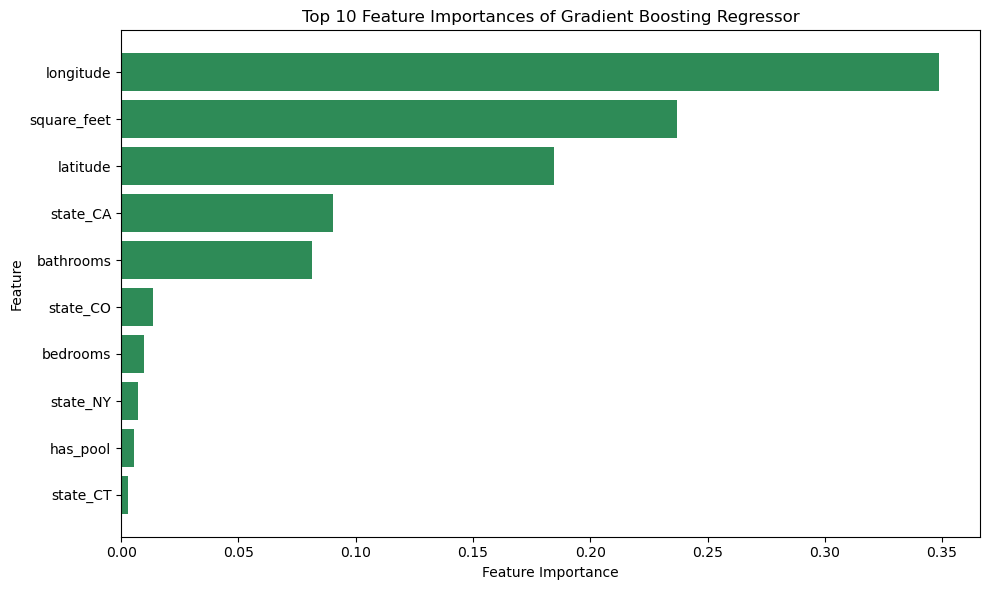

In [108]:
# =========================================================
# 19. FEATURE-IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    color="seagreen"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 10 Feature Importances of "
    "Gradient Boosting Regressor"
)

plt.tight_layout()
plt.show()

In [109]:
# =========================================================
# 20. FINAL MODEL SUMMARY
# =========================================================

print("Final Gradient Boosting Regressor Summary")
print("-----------------------------------------")

print("\nDataset:")
print("Total observations:", len(df))
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nBest Parameters:")
for parameter, value in best_parameters.items():
    print(f"{parameter}: {value}")

print(
    "\nBest Cross-Validation RMSE:",
    round(best_cv_rmse, 2)
)

print("\nFinal Testing Performance:")
print(f"Testing MAE:  USD {tuned_test_mae:.2f}")
print(f"Testing RMSE: USD {tuned_test_rmse:.2f}")
print(f"Testing R²:   {tuned_test_r2:.4f}")

print(
    "\nNumber of features after preprocessing:",
    len(clean_feature_names)
)

Final Gradient Boosting Regressor Summary
-----------------------------------------

Dataset:
Total observations: 89730
Training observations: 71784
Testing observations: 17946

Best Parameters:
subsample: 0.9
n_estimators: 200
min_samples_split: 10
min_samples_leaf: 4
max_depth: 4
learning_rate: 0.1

Best Cross-Validation RMSE: 430.47

Final Testing Performance:
Testing MAE:  USD 259.31
Testing RMSE: USD 428.81
Testing R²:   0.7313

Number of features after preprocessing: 63



---


# 5.0 Evaluation


In [110]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Testing MAE': [367.70, 235.97, 245.24, 259.31],
    'Testing RMSE': [590.86, 438.24, 412.32, 428.81],
    'Testing R²': [0.4899, 0.7194, 0.7516, 0.7313]
})

results

,Model,Testing MAE,Testing RMSE,Testing R²
0,Linear Regression,367.70,590.86,0.4899
1,Decision Tree,235.97,438.24,0.7194
2,Random Forest,245.24,412.32,0.7516
3,Gradient Boosting,259.31,428.81,0.7313


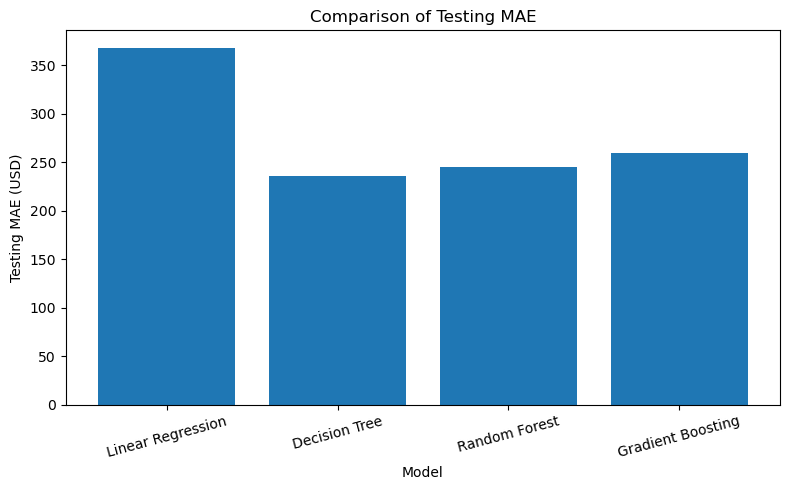

In [111]:
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['Testing MAE'])

plt.title('Comparison of Testing MAE')
plt.xlabel('Model')
plt.ylabel('Testing MAE (USD)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

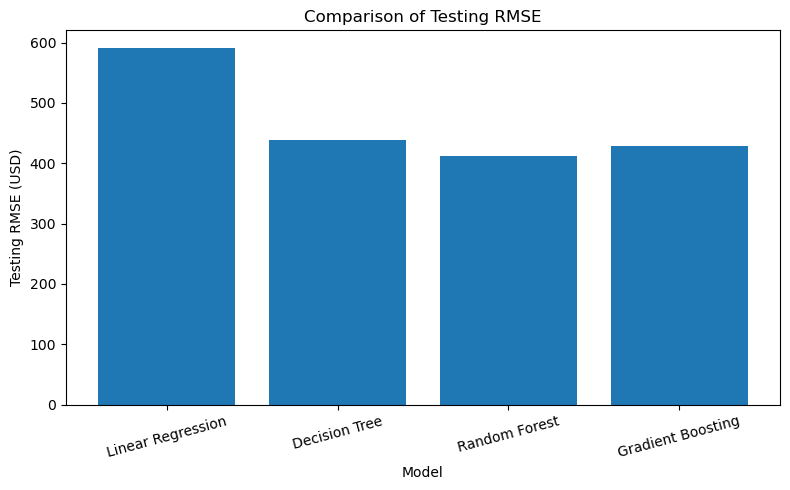

In [112]:
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['Testing RMSE'])

plt.title('Comparison of Testing RMSE')
plt.xlabel('Model')
plt.ylabel('Testing RMSE (USD)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

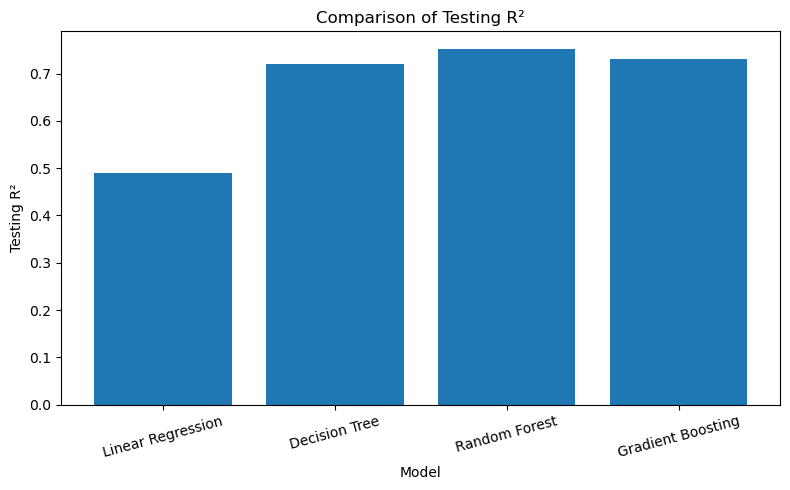

In [113]:
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['Testing R²'])

plt.title('Comparison of Testing R²')
plt.xlabel('Model')
plt.ylabel('Testing R²')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [114]:
import pandas as pd

table_5_2 = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Training MAE (USD)": [
        369.01,
        188.75,
        192.65,
        254.37
    ],
    "Testing MAE(USD)": [
        367.70,
        235.97,
        245.24,
        259.31
    ],
    "Training RMSE (USD)": [
        599.08,
        328.30,
        285.85,
        396.23
    ],
    "Testing RMSE (USD)": [
        590.86,
        438.24,
        412.32,
        428.81
    ],
    "Training R²": [
        0.4816,
        0.8443,
        0.8820,
        0.7732
    ],
    "Testing R²": [
        0.4899,
        0.7194,
        0.7516,
        0.7313
    ]
})

table_5_2

,Model,Training MAE (USD),Testing MAE(USD),Training RMSE (USD),Testing RMSE (USD),Training R²,Testing R²
0,Linear Regression,369.01,367.70,599.08,590.86,0.4816,0.4899
1,Decision Tree,188.75,235.97,328.30,438.24,0.8443,0.7194
2,Random Forest,192.65,245.24,285.85,412.32,0.8820,0.7516
3,Gradient Boosting,254.37,259.31,396.23,428.81,0.7732,0.7313
